# Gradient Descent & Optimization

有了精确的梯度引擎，开始研究"怎么高效下山"：收敛条件、学习率调度、SGD 的噪声、动量、自适应方法（AdaGrad/RMSProp/Adam）、停止条件与实操经验。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib

# 中文字体：避免图上中文显示为方块（macOS 用苹方，Windows 用微软雅黑）
matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False   # 修复负号显示为方块

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 收敛性分析：从最简单的情况开始


### 1.1 一维二次型

对 $f(x) = \tfrac12 a x^2$（$a>0$），梯度下降 $x \leftarrow x - \alpha\,ax$，即：

$$x_{k+1} = (1 - a\alpha)\,x_k$$

收敛当且仅当 $|1 - a\alpha| < 1$，即 $0 < \alpha < 2/a$。**最优学习率 $\alpha^* = 1/a$**（一步到位）。多维推广：$\alpha < 2/\lambda_{\max}(H)$。


In [2]:
a = 2.0
print("f(x) = ½·2x²，最大稳定学习率 = 2/a = 1.0")
for alpha in [0.5/a, 0.99/a, 1.0/a, 1.5/a, 2.0/a, 2.1/a]:
    ratio = abs(1 - a*alpha)          # 每步的缩放因子
    verdict = '收敛' if ratio < 1 else ('极限环' if ratio == 1 else '发散')
    print(f"α = {alpha:.3f} = {a*alpha:.2f}/a   |1-aα| = {ratio:.3f}   → {verdict}")


f(x) = ½·2x²，最大稳定学习率 = 2/a = 1.0
α = 0.250 = 0.50/a   |1-aα| = 0.500   → 收敛
α = 0.495 = 0.99/a   |1-aα| = 0.010   → 收敛
α = 0.500 = 1.00/a   |1-aα| = 0.000   → 收敛
α = 0.750 = 1.50/a   |1-aα| = 0.500   → 收敛
α = 1.000 = 2.00/a   |1-aα| = 1.000   → 极限环
α = 1.050 = 2.10/a   |1-aα| = 1.100   → 发散


## 2. 学习率调度


| 调度 | 公式 | 特点 |
|------|------|------|
| 固定 | $\alpha_k = \alpha$ | 简单；太大发散/震荡，太小龟速 |
| 步长衰减 | $\alpha_k = \alpha/(1+\beta k)$ | 前期大步探索，后期精细收敛 |
| 余弦退火 | $\alpha_k = \tfrac{\alpha}{2}(1+\cos\tfrac{\pi k}{K})$ | 平滑地从大到小 |

同一初始学习率，调度决定能否收敛：


Text(0.5, 1.0, '学习率调度对比：同样初始学习率，调度决定能否收敛')

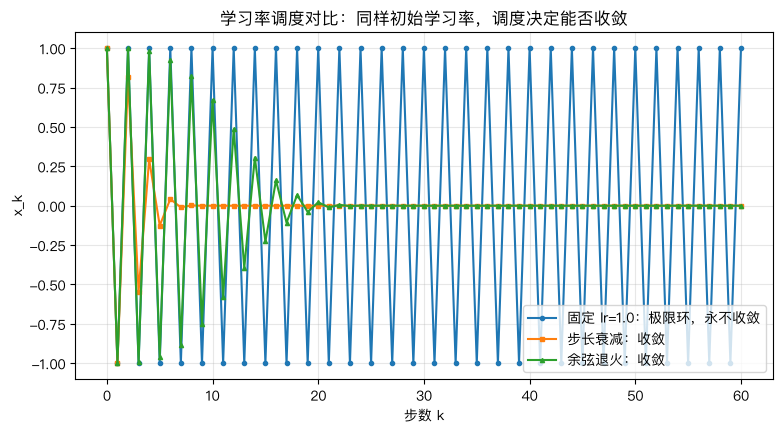

In [3]:
f, df = lambda x: x**2, lambda x: 2*x

def run(df, x0, lr, steps, schedule=None):
    xs = [x0]; x = x0
    for k in range(steps):
        a = lr * schedule(k) if schedule else lr
        x = x - a * df(x)
        xs.append(x)
    return np.array(xs)

steps = 60
t_fixed  = run(df, 1.0, 1.0, steps)                    # lr=1.0：x_{k+1} = -x_k，极限环
t_decay  = run(df, 1.0, 1.0, steps, schedule=lambda k: 1/(1 + 0.1*k))
t_cosine = run(df, 1.0, 1.0, steps, schedule=lambda k: 0.5*(1 + np.cos(np.pi*k/steps)))

plt.figure(figsize=(9, 4.5))
plt.plot(t_fixed, 'o-', markersize=3, label='固定 lr=1.0：极限环，永不收敛')
plt.plot(t_decay, 's-', markersize=3, label='步长衰减：收敛')
plt.plot(t_cosine, '^-', markersize=3, label='余弦退火：收敛')
plt.xlabel('步数 k'); plt.ylabel('x_k')
plt.legend(); plt.grid(alpha=0.3)
plt.title('学习率调度对比：同样初始学习率，调度决定能否收敛')


## 3. SGD：噪声梯度的几何


全批量梯度需要在整个数据集上算期望，太贵。SGD 用**一个样本/一个小批量**的梯度代替：

$$\tilde{g} = \nabla L_i(w), \qquad \mathbb{E}[\tilde{g}] = \nabla L(w)$$

随机梯度是真实梯度的**无偏估计**：平均方向正确，单步带噪声。噪声的好处是可能跳出浅谷（隐式正则），代价是收敛路径抖动。


Text(0.5, 1.0, '随机梯度 = 真实梯度的无偏估计：平均方向对，单步抖动')

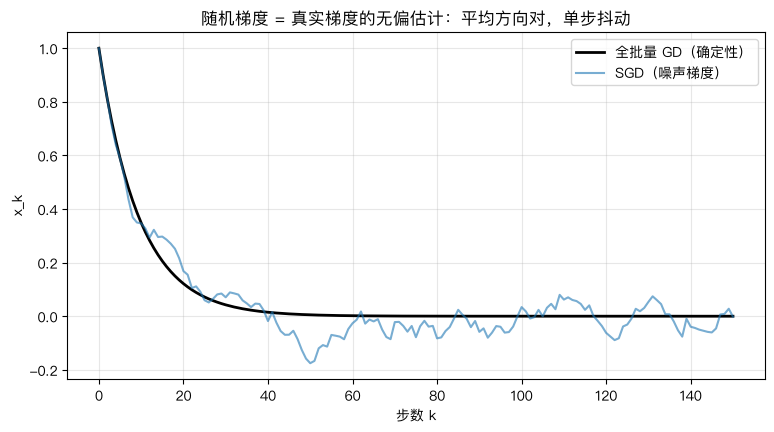

In [4]:
def sgd_noisy(df, x0, lr, steps, noise=0.5, seed=0):
    rng = np.random.default_rng(seed)
    xs = [x0]; x = x0
    for _ in range(steps):
        g = df(x) + noise * rng.standard_normal()   # 无偏但有噪声的梯度
        x = x - lr * g
        xs.append(x)
    return np.array(xs)

def gd(df, x0, lr, steps):
    xs = [x0]; x = x0
    for _ in range(steps):
        x = x - lr * df(x)
        xs.append(x)
    return np.array(xs)

f, df = lambda x: x**2, lambda x: 2*x
traj_gd  = gd(df, 1.0, 0.05, 150)
traj_sgd = sgd_noisy(df, 1.0, 0.05, 150)

plt.figure(figsize=(9, 4.5))
plt.plot(traj_gd, 'k-', linewidth=2, label='全批量 GD（确定性）')
plt.plot(traj_sgd, alpha=0.6, label='SGD（噪声梯度）')
plt.xlabel('步数 k'); plt.ylabel('x_k')
plt.legend(); plt.grid(alpha=0.3)
plt.title('随机梯度 = 真实梯度的无偏估计：平均方向对，单步抖动')


## 4. 动量


$$v \leftarrow \beta v + g, \qquad x \leftarrow x - \alpha v$$

- 直觉：梯度像力，$v$ 像速度，$\beta$ 是摩擦系数（典型 0.9）
- 病态方向上：正交方向（陡峭）的振荡被平均抵消，主轴方向（平坦）的速度持续累积
- 效果：学习率被"放大"到 $\alpha/(1-\beta)$，同时抑制振荡

代码在病态二次型上对比 GD 与动量：


Text(0.5, 1.0, '病态二次型：动量加速主轴方向、抑制陡峭方向振荡')

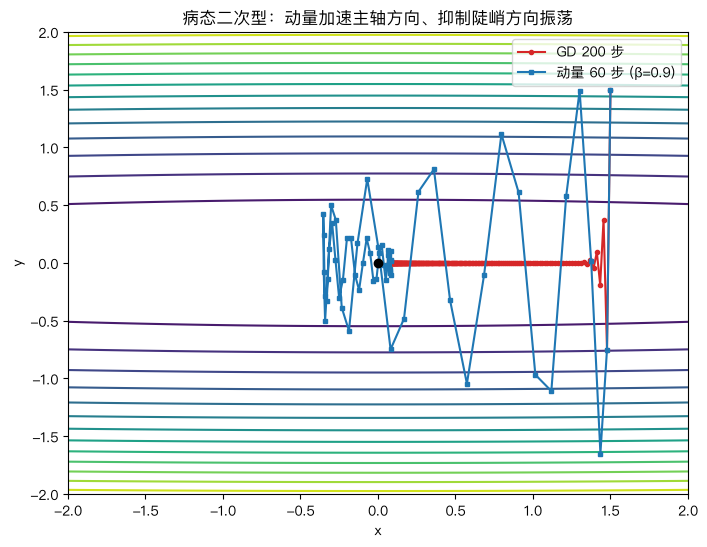

In [5]:
H = np.array([[1., 0.], [0., 100.]])
g = lambda x: H @ x

def gd(x0, lr, steps):
    xs = [x0]; x = x0.copy()
    for _ in range(steps):
        x = x - lr * g(x)
        xs.append(x.copy())
    return np.array(xs)

def momentum(x0, lr, beta, steps):
    xs = [x0]; x = x0.copy(); v = np.zeros_like(x)
    for _ in range(steps):
        v = beta * v + g(x)
        x = x - lr * v
        xs.append(x.copy())
    return np.array(xs)

x0 = np.array([1.5, 1.5])
gd_traj  = gd(x0, 0.015, 200)
mom_traj = momentum(x0, 0.015, 0.9, 60)

xs = np.linspace(-2, 2, 100); ys = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(xs, ys)
Z = 0.5 * (X**2 + 100*Y**2)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=15, cmap='viridis')
plt.plot(gd_traj[:, 0], gd_traj[:, 1], 'o-', color='tab:red', markersize=3, label='GD 200 步')
plt.plot(mom_traj[:, 0], mom_traj[:, 1], 's-', color='tab:blue', markersize=3, label='动量 60 步 (β=0.9)')
plt.scatter([0], [0], color='black', zorder=5)
plt.legend(); plt.xlabel('x'); plt.ylabel('y')
plt.title('病态二次型：动量加速主轴方向、抑制陡峭方向振荡')


## 5. 自适应学习率：AdaGrad / RMSProp / Adam


| 方法 | 更新式 | 核心思想 |
|------|--------|---------|
| AdaGrad | $x \leftarrow x - \tfrac{\alpha}{\sqrt{G}+\varepsilon}g$，$G{+}{=}g^2$ | 历史梯度平方累积，陡峭方向自动减小步长 |
| RMSProp | $v \leftarrow \beta v + (1{-}\beta)g^2$，$x \leftarrow x - \tfrac{\alpha}{\sqrt{v}+\varepsilon}g$ | 滑动平均代替累积，解决 AdaGrad 步长单调趋零 |
| Adam | $m{=}\beta_1 m{+}(1{-}\beta_1)g$，$v{=}\beta_2 v{+}(1{-}\beta_2)g^2$，偏差修正后 $x \leftarrow x - \alpha\,\tfrac{\hat{m}}{\sqrt{\hat{v}}+\varepsilon}$ | 动量 + RMSProp 结合，深度学习默认优化器 |

收敛速度对比（病态二次型，到最优解的距离）：


Text(0.5, 1.0, '每参数自适应步长让 Adam 在病态问题上最快')

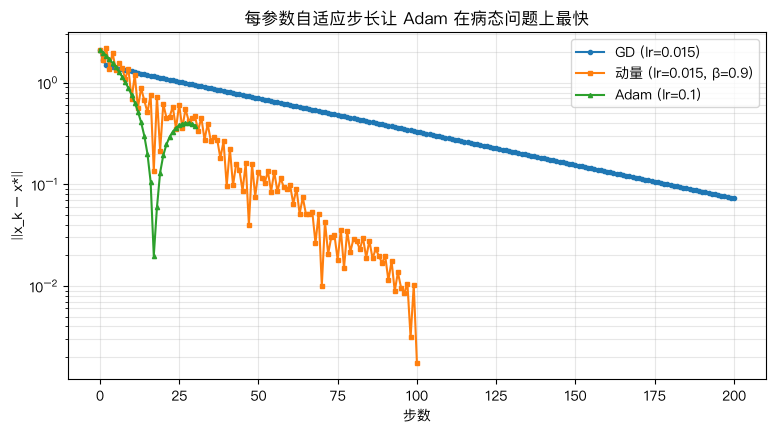

In [6]:
def adam(x0, lr, steps, beta1=0.9, beta2=0.999, eps=1e-8):
    xs = [x0]; x = x0.copy()
    m = np.zeros_like(x); v2 = np.zeros_like(x)
    for k in range(1, steps+1):
        g = H @ x
        m  = beta1*m + (1-beta1)*g
        v2 = beta2*v2 + (1-beta2)*g**2
        mh  = m  / (1 - beta1**k)          # 偏差修正
        vh  = v2 / (1 - beta2**k)
        x = x - lr * mh / (np.sqrt(vh) + eps)
        xs.append(x.copy())
    return np.array(xs)

def gd2(x0, lr, steps):
    xs = [x0]; x = x0.copy()
    for _ in range(steps):
        x = x - lr * H @ x
        xs.append(x.copy())
    return np.array(xs)

x0 = np.array([1.5, 1.5])
gd_traj   = gd2(x0, 0.015, 200)
mom_traj  = momentum(x0, 0.015, 0.9, 100)
adam_traj = adam(x0, 0.1, 30)

plt.figure(figsize=(9, 4.5))
plt.semilogy(np.linalg.norm(gd_traj, axis=1),   'o-', markersize=3, label='GD (lr=0.015)')
plt.semilogy(np.linalg.norm(mom_traj, axis=1),  's-', markersize=3, label='动量 (lr=0.015, β=0.9)')
plt.semilogy(np.linalg.norm(adam_traj, axis=1), '^-', markersize=3, label='Adam (lr=0.1)')
plt.xlabel('步数'); plt.ylabel('‖x_k − x*‖')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.title('每参数自适应步长让 Adam 在病态问题上最快')


## 6. 停止条件


实际训练不会固定步数跑到底，常用停止条件：

- **梯度范数** $\|\nabla L\| < \tau$：接近驻点（最常用）
- **相对损失变化** $|L_k - L_{k-1}|/L_k < \tau$：损失平台期
- 早停（early stopping）：验证集损失不再下降即停（防过拟合）


In [7]:
f = lambda x: 0.2*x**4 - 1.5*x**2 + 0.8*x + 4
df = lambda x: 0.8*x**3 - 3*x + 0.8
x, lr = 2.8, 0.01
for k in range(500):
    g = df(x)
    if abs(g) < 1e-4:                 # 梯度范数阈值
        print(f"第 {k} 步停止：|∇f| = {abs(g):.2e} < 1e-4，x = {x:.6f}")
        break
    x = x - lr * g
else:
    print("达到最大步数 500 未收敛")


第 211 步停止：|∇f| = 9.73e-05 < 1e-4，x = 1.786111


## 7. 深度学习的实操经验


- **学习率是最重要的超参数**：先找"能发散的最大 lr"，再回退一个量级
- **批量与学习率线性缩放**：batch size ×2 → 学习率 ×2（线性缩放规则，线性区有效）
- **warmup**：前几百步用小学习率热身，防止初始大梯度破坏训练
- **梯度裁剪**：$\|g\| > c$ 时缩放到 $c$，防止爆炸
- **Adam 的默认 lr=1e-3** 在多数任务上直接可用；SGD 需要更多调度，但最终精度常更好


## 总结


| 工具 | 解决的问题 |
|------|-----------|
| 收敛条件 $\alpha < 2/\lambda_{\max}$ | 知道学习率的上界 |
| 调度 | 前期探索、后期收敛 |
| SGD | 大数据集上的低成本无偏梯度 |
| 动量 | 抑制振荡、加速平坦方向 |
| Adam | 每参数自适应步长，病态问题鲁棒 |
| 停止条件 | 省算力、防过拟合 |


## 课后练习


1. **证明**：一维二次型 $f = \tfrac12 a x^2$ 的 GD 收敛条件 $|1-a\alpha|<1$，并求最优学习率。
2. **动量分析**：解释为什么 $\beta \to 1$ 相当于把学习率放大到 $\alpha/(1-\beta)$（提示：几何级数求和）。
3. **对比实验**：在 $f = x^2 + 100y^2$ 上跑 GD / 动量 / Adam 各 50 步，打印每 10 步的 $\|x_k - x^*\|$ 对比。
4. **mini-batch 模拟**：给线性回归 $y = 2x + \varepsilon$ 造 100 个样本，对比 full-batch 与 batch=10 的收敛轨迹。
5. **复现发散**：取 $\alpha = 2.1/a$ 跑 20 步，画出 $|x_k|$ 指数增长，验证收敛条件。
